# 03 — Abandoned-Road Detector (v0.6)

Replaces the v0.1–v0.5 pad detector, per the project guide
`Detecting abandoned roads beneath forest canopy with LiDAR and Python.md`.

Rationale: the v0.4 local-anomaly pad detector produced **linear** smooth features clustered near documented wells (p < 0.001). Those linear features are best understood as **access-road remnants** — the roads that served the wells. Roads persist longer than pads, leave larger detectable signatures (100s of m² per road-km), and converge on wellheads. Detecting them is the right way to infer well locations at this tile's preservation state.

**Pipeline** (rule-based, no training data):
1. Read LRM_25 and LRM_51 (stage C outputs from `02_derivatives.ipynb`).
2. Apply scikit-image ridge filter (`meijering`) to `−LRM` — sunken road beds light up.
3. Threshold at ridge-response p90.
4. Binary closing (r=2) to connect fragments.
5. Connected components → keep components with **eccentricity ≥ 0.90** (elongated) and **area ≥ 200 m²**.
6. Skeletonize to single-pixel centrelines.
7. Vectorize as LineStrings.
8. Per-segment attributes: length_m, mean_lrm, nearest-well distance, well_id.
9. GeoPackage + Parquet output.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from scipy import ndimage as ndi
from skimage.filters import meijering
from skimage.morphology import skeletonize, remove_small_objects, binary_closing, disk
from skimage.measure import regionprops, label
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
from datetime import datetime
import uuid

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
CAND  = DERIV / 'candidates'
LOGS  = PROJECT / 'docs'
CAND.mkdir(parents=True, exist_ok=True)

DETECTION_METHOD = 'road_v0.9_relaxed'
RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]
print('run_id:', RUN_ID)

def rd(name, nd_val=None):
    with rasterio.open(DERIV / name) as ds:
        a = ds.read(1).astype(np.float32)
        nd = nd_val if nd_val is not None else ds.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        return a, ds.transform, ds.crs

lrm_25, transform, crs = rd('lrm_25.tif', -9999.0)
lrm_51, _, _           = rd('lrm_51.tif', -9999.0)
op_neg, _, _           = rd('openness_neg.tif', -9999.0)
slope,  _, _           = rd('slope.tif')
with rasterio.open(DERIV / 'ground_density.tif') as ds:
    density = ds.read(1)
with rasterio.open(DERIV / 'hillshade.tif') as ds:
    hs = ds.read(1)

H, W = lrm_25.shape
cs = float(transform.a)
X0, Y1 = transform.c, transform.f
X1 = X0 + W * cs
Y0 = Y1 - H * cs
print(f'grid {H}x{W} @ {cs} m')

wells = gpd.read_file(DERIV / 'wells_in_tile.gpkg').to_crs(crs)
print(f'wells in tile: {len(wells)}')

C:\Users\colto\AppData\Local\Temp\ipykernel_42500\802506668.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]


run_id: 20260430T175948Z-2e7e97


grid 1500x1500 @ 1.0 m
wells in tile: 107


## Thresholds (v0.6 — tune per WellSight rule)

In [2]:
TH = {
    # Meijering sigmas: White et al. (2010, PE&RS 76:1079-1087) report forest
    # access roads at 3-5 m width; sigma 1-3 covers 2-9 m detected widths.
    "ridge_sigmas":          (1.0, 2.0, 3.0),
    "ridge_response_pct":    85.0,
    "closing_radius_cells":  2,
    "min_component_area_m2": 120.0,
    "min_eccentricity":      0.82,
    "min_segment_length_m":  30.0,
    "ground_density_min":    1.0,
    # Kang et al. (2014, NETL): 50-200 m for pre-GPS PA wells.
    "positional_uncert_m": 100.0,
    # Cross-section: xsec_edge widths 2-12 m per Clode et al. (2007),
    # White et al. (2010) for single-track to two-lane access roads.
    "xsec_spacing_m":        5.0,
    "xsec_half_width_m":    15.0,
    "xsec_edge_min_width_m": 2.0,
    "xsec_edge_max_width_m":12.0,
}
for k, v in TH.items():
    print(f"  {k:<24} {v}")

  ridge_sigmas             (1.0, 2.0, 3.0)
  ridge_response_pct       85.0
  closing_radius_cells     2
  min_component_area_m2    120.0
  min_eccentricity         0.82
  min_segment_length_m     30.0
  ground_density_min       1.0
  positional_uncert_m      100.0
  xsec_spacing_m           5.0
  xsec_half_width_m        15.0
  xsec_edge_min_width_m    2.0
  xsec_edge_max_width_m    12.0


## 1. Ridge response (Meijering tubular filter on −LRM)

`meijering` picks out bright tubular (ridge-like) structures. Sunken roads in the
DEM show up as negative values in LRM, so we invert the sign before filtering.
Multi-scale σ captures roads of varying width.

In [3]:
def ridge_response(lrm, sigmas):
    v = np.isfinite(lrm)
    x = np.where(v, -lrm, 0).astype(np.float32)
    r = meijering(x, sigmas=sigmas, black_ridges=False)
    r = np.where(v, r, 0).astype(np.float32)
    return r

# Sum the two-scale responses (LRM_25 tunes narrow, LRM_51 tunes wider)
r_25 = ridge_response(lrm_25, TH['ridge_sigmas'])
r_51 = ridge_response(lrm_51, TH['ridge_sigmas'])
ridge = np.maximum(r_25, r_51)
print(f'ridge response  p50={np.nanpercentile(ridge,50):.4f}  p95={np.nanpercentile(ridge,95):.4f}')

ridge response  p50=0.0190  p95=0.1625


## 2. Threshold → clean → keep elongated components

In [4]:
valid = np.isfinite(slope) & (density >= TH['ground_density_min'])
thresh = np.nanpercentile(ridge[valid], TH['ridge_response_pct'])
print(f'ridge threshold (p{TH["ridge_response_pct"]:.0f}): {thresh:.4f}')

bm = valid & (ridge >= thresh)
print(f'above threshold: {100*bm.mean():.2f}% of tile')

bm = binary_closing(bm, footprint=disk(TH['closing_radius_cells']))
bm = remove_small_objects(bm, min_size=int(TH['min_component_area_m2'] / (cs*cs)))
print(f'after closing + small-object removal: {100*bm.mean():.2f}% of tile')

labels = label(bm)
props = regionprops(labels)
keep_labels = {p.label for p in props
               if p.eccentricity >= TH['min_eccentricity']
               and p.area * cs * cs >= TH['min_component_area_m2']}
print(f'components: {len(props)} total, {len(keep_labels)} elongated (ecc >= {TH["min_eccentricity"]})')
elongated = np.isin(labels, list(keep_labels))

ridge threshold (p85): 0.0750
above threshold: 13.73% of tile
after closing + small-object removal: 13.52% of tile
components: 267 total, 229 elongated (ecc >= 0.82)


## 3. Skeletonize → vectorize as LineStrings

In [5]:
skel = skeletonize(elongated)
skel_labels, n_skel = ndi.label(skel, structure=np.ones((3,3), dtype=bool))
print(f'skeleton components: {n_skel}')

# For each component, trace an ordered path (greedy nearest-neighbour from an endpoint).
def trace_skeleton_component(coords):
    if len(coords) == 1:
        return coords
    # find endpoints (pixels with exactly one neighbour in the same component)
    cs_set = set(map(tuple, coords))
    ends = []
    for p in coords:
        nbrs = sum(1 for dy in (-1,0,1) for dx in (-1,0,1)
                   if (dy or dx) and (p[0]+dy, p[1]+dx) in cs_set)
        if nbrs <= 1:
            ends.append(tuple(p))
    start = ends[0] if ends else tuple(coords[0])
    # BFS from start to farthest pixel, then from that to farthest
    def bfs_far(seed):
        seen = {seed: None}
        front = [seed]
        last = seed
        while front:
            nxt = []
            for p in front:
                for dy in (-1,0,1):
                    for dx in (-1,0,1):
                        if not dy and not dx: continue
                        q = (p[0]+dy, p[1]+dx)
                        if q in cs_set and q not in seen:
                            seen[q] = p
                            nxt.append(q); last = q
            front = nxt
        return last, seen
    a, _ = bfs_far(start)
    b, parent = bfs_far(a)
    # reconstruct path a..b
    path = []
    cur = b
    while cur is not None:
        path.append(cur); cur = parent[cur]
    path.reverse()
    return np.array(path)

segments = []
seg_len_m = []
mean_lrm = []
cand_id = []
for lab in range(1, n_skel + 1):
    where = np.argwhere(skel_labels == lab)
    if len(where) < 3:
        continue
    path_px = trace_skeleton_component(where)
    xs = X0 + (path_px[:, 1] + 0.5) * cs
    ys = Y1 - (path_px[:, 0] + 0.5) * cs
    coords = list(zip(xs, ys))
    line = LineString(coords)
    if line.length < TH['min_segment_length_m']:
        continue
    segments.append(line)
    seg_len_m.append(line.length)
    r, c = path_px[:, 0], path_px[:, 1]
    mean_lrm.append(float(np.nanmean(lrm_25[r, c])))
    cand_id.append(lab)

print(f'kept {len(segments)} road segments (>= {TH["min_segment_length_m"]:.0f} m)')
roads = gpd.GeoDataFrame({
    'cand_id': cand_id,
    'length_m': seg_len_m,
    'mean_lrm_25': mean_lrm,
    'geometry': segments,
}, crs=crs)

skeleton components: 229


kept 191 road segments (>= 30 m)


## 4. Nearest-well distance per segment (shapely; uses line geometry, not centroid)

In [6]:
def nearest_well(line, well_geoms):
    ds = line.distance(well_geoms)  # GeoSeries broadcast
    i = ds.idxmin()
    return float(ds.iloc[i]), wells.iloc[i].Well_ident

nw_d, nw_id = [], []
for line in roads.geometry:
    d, wid = nearest_well(line, wells.geometry)
    nw_d.append(d); nw_id.append(wid)
roads['nearest_well_m'] = nw_d
roads['nearest_well_id'] = nw_id
roads['inside_positional_uncertainty'] = roads['nearest_well_m'] <= TH['positional_uncert_m']

# Confidence: combination of normalized length, LRM depth, and well proximity.
# Proximity is NOT used for the random-baseline validation (that would be circular);
# we only use ridge/length/LRM-depth here.
len_score = np.clip(roads['length_m'] / 200.0, 0, 1)            # saturate at 200 m
depth_score = np.clip(-roads['mean_lrm_25'] / 0.5, 0, 1)        # −0.5 m LRM -> 1.0
roads['confidence_score'] = (0.5 * len_score + 0.5 * depth_score).astype(np.float32)
roads['confidence_label'] = np.where(roads['confidence_score'] > 0.70, 'probable', 'candidate')
roads['detection_method'] = DETECTION_METHOD
roads['run_id'] = RUN_ID

print(f'median length: {roads.length_m.median():.1f} m, p95: {roads.length_m.quantile(.95):.1f} m')
print(f'median nearest-well: {roads.nearest_well_m.median():.1f} m')
print(f'segments within {TH["positional_uncert_m"]:.0f} m of any well: {roads.inside_positional_uncertainty.sum()} / {len(roads)}')

median length: 56.8 m, p95: 286.9 m
median nearest-well: 42.7 m
segments within 100 m of any well: 164 / 191


## 5. Export — `candidates_roads.gpkg` + `candidates_roads.parquet`

## 6b. Cross-section attribution — width and cut depth per segment

For each segment, sample perpendicular elevation profiles every `xsec_spacing_m`
along the centreline. Road edges appear as local maxima in the absolute
gradient of the cross-section (slope breaks at the cut rim). Width = distance
between the nearest left/right slope-break peaks; cut depth = peak elevation
minus centre elevation. Returned: median and p90 of width and cut depth.


In [7]:
from scipy.signal import find_peaks

# DEM for cross-section sampling
with rasterio.open(DERIV / 'dem_1m.tif') as ds:
    dem = ds.read(1).astype(np.float32)
    dem_nd = ds.nodata
if dem_nd is not None:
    dem = np.where(dem == dem_nd, np.nan, dem)

def sample_dem(xs, ys):
    """Bilinear sample of DEM at world coords (xs, ys)."""
    c = (xs - X0) / cs - 0.5
    r = (Y1 - ys) / cs - 0.5
    c0 = np.floor(c).astype(np.int64); c1 = c0 + 1
    r0 = np.floor(r).astype(np.int64); r1 = r0 + 1
    fc = (c - c0).astype(np.float32); fr = (r - r0).astype(np.float32)
    c0 = np.clip(c0, 0, W-1); c1 = np.clip(c1, 0, W-1)
    r0 = np.clip(r0, 0, H-1); r1 = np.clip(r1, 0, H-1)
    z00 = dem[r0, c0]; z01 = dem[r0, c1]; z10 = dem[r1, c0]; z11 = dem[r1, c1]
    return ((1-fr)*((1-fc)*z00 + fc*z01) + fr*((1-fc)*z10 + fc*z11)).astype(np.float32)

def segment_attrs(line):
    """Median/p90 width and cut-depth across cross-sections of `line`."""
    total = line.length
    if total < TH["xsec_spacing_m"] * 2:
        return np.nan, np.nan, np.nan, np.nan, 0
    n_xsec = int(total / TH["xsec_spacing_m"]) + 1
    widths = []
    depths = []
    half = TH["xsec_half_width_m"]
    d_arr = np.linspace(-half, half, int(2 * half) + 1).astype(np.float32)
    for i in range(n_xsec):
        s = min(i * TH["xsec_spacing_m"], total)
        pt = line.interpolate(s)
        p_ahead = line.interpolate(min(s + 0.5, total))
        p_back  = line.interpolate(max(s - 0.5, 0))
        tx = p_ahead.x - p_back.x; ty = p_ahead.y - p_back.y
        tl = np.hypot(tx, ty) or 1.0
        tx /= tl; ty /= tl
        nx, ny = -ty, tx
        xs = pt.x + d_arr * nx
        ys = pt.y + d_arr * ny
        z = sample_dem(xs, ys)
        if not np.all(np.isfinite(z)):
            continue
        # Detrend the linear slope (we want cross-section curvature, not hillslope)
        trend = np.polyfit(d_arr, z, 1)
        z_det = z - (trend[0] * d_arr + trend[1])
        # Gradient magnitude picks out slope breaks
        gmag = np.abs(np.gradient(z_det))
        # Split at centre (idx == half index); find strongest peak on each side
        centre = len(z_det) // 2
        left_gmag = gmag[:centre]; right_gmag = gmag[centre+1:]
        if left_gmag.size == 0 or right_gmag.size == 0:
            continue
        l_peaks, _ = find_peaks(left_gmag, height=np.percentile(left_gmag, 70))
        r_peaks, _ = find_peaks(right_gmag, height=np.percentile(right_gmag, 70))
        if len(l_peaks) == 0 or len(r_peaks) == 0:
            continue
        l_edge = l_peaks[-1]               # closest peak to centre
        r_edge = centre + 1 + r_peaks[0]   # closest peak to centre
        w = float(d_arr[r_edge] - d_arr[l_edge])
        if w < TH["xsec_edge_min_width_m"] or w > TH["xsec_edge_max_width_m"]:
            continue
        # Cut depth: higher of the two rim elevations minus centre elevation
        depth = float(max(z_det[l_edge], z_det[r_edge]) - z_det[centre])
        if depth < 0:
            depth = 0.0
        widths.append(w); depths.append(depth)
    if not widths:
        return np.nan, np.nan, np.nan, np.nan, 0
    return (float(np.median(widths)),
            float(np.percentile(widths, 90)),
            float(np.median(depths)),
            float(np.percentile(depths, 90)),
            int(len(widths)))

print("computing cross-section attributes for each segment...")
attrs = [segment_attrs(g) for g in roads.geometry]
roads["median_width_m"]     = [a[0] for a in attrs]
roads["p90_width_m"]        = [a[1] for a in attrs]
roads["median_cut_depth_m"] = [a[2] for a in attrs]
roads["p90_cut_depth_m"]    = [a[3] for a in attrs]
roads["n_xsec_valid"]       = [a[4] for a in attrs]

have_xsec = roads["n_xsec_valid"] > 0
print(f"segments with >= 1 valid cross-section: {have_xsec.sum()} / {len(roads)}")
if have_xsec.any():
    w = roads.loc[have_xsec, "median_width_m"]
    d = roads.loc[have_xsec, "median_cut_depth_m"]
    print(f"median_width_m     : p25={w.quantile(.25):.2f} p50={w.quantile(.5):.2f} p75={w.quantile(.75):.2f}")
    print(f"median_cut_depth_m : p25={d.quantile(.25):.2f} p50={d.quantile(.5):.2f} p75={d.quantile(.75):.2f}")


computing cross-section attributes for each segment...


segments with >= 1 valid cross-section: 191 / 191
median_width_m     : p25=6.00 p50=7.50 p75=8.50
median_cut_depth_m : p25=0.30 p50=0.37 p75=0.50


In [8]:
export = roads.sort_values("confidence_score", ascending=False).reset_index(drop=True)
export["cand_id"] = np.arange(1, len(export) + 1, dtype=np.int64)

COLS = ["cand_id", "detection_method", "run_id", "confidence_score", "confidence_label",
        "length_m", "mean_lrm_25",
        "median_width_m", "p90_width_m", "median_cut_depth_m", "p90_cut_depth_m",
        "n_xsec_valid",
        "nearest_well_m", "nearest_well_id", "inside_positional_uncertainty",
        "geometry"]
export = export[COLS]

GPKG = CAND / "candidates_roads.gpkg"
PARQ = CAND / "candidates_roads.parquet"
GPKG.unlink(missing_ok=True)
if len(export) > 0:
    export.to_file(GPKG, layer="candidates_roads", driver="GPKG")
    export.drop(columns="geometry").to_parquet(PARQ, index=False)
    print(f"wrote {GPKG.name} ({len(export)} rows) and {PARQ.name}")
else:
    print("no road segments survived — nothing written")


wrote candidates_roads.gpkg (191 rows) and candidates_roads.parquet


## 6. QA — centrelines on hillshade, wells overlaid

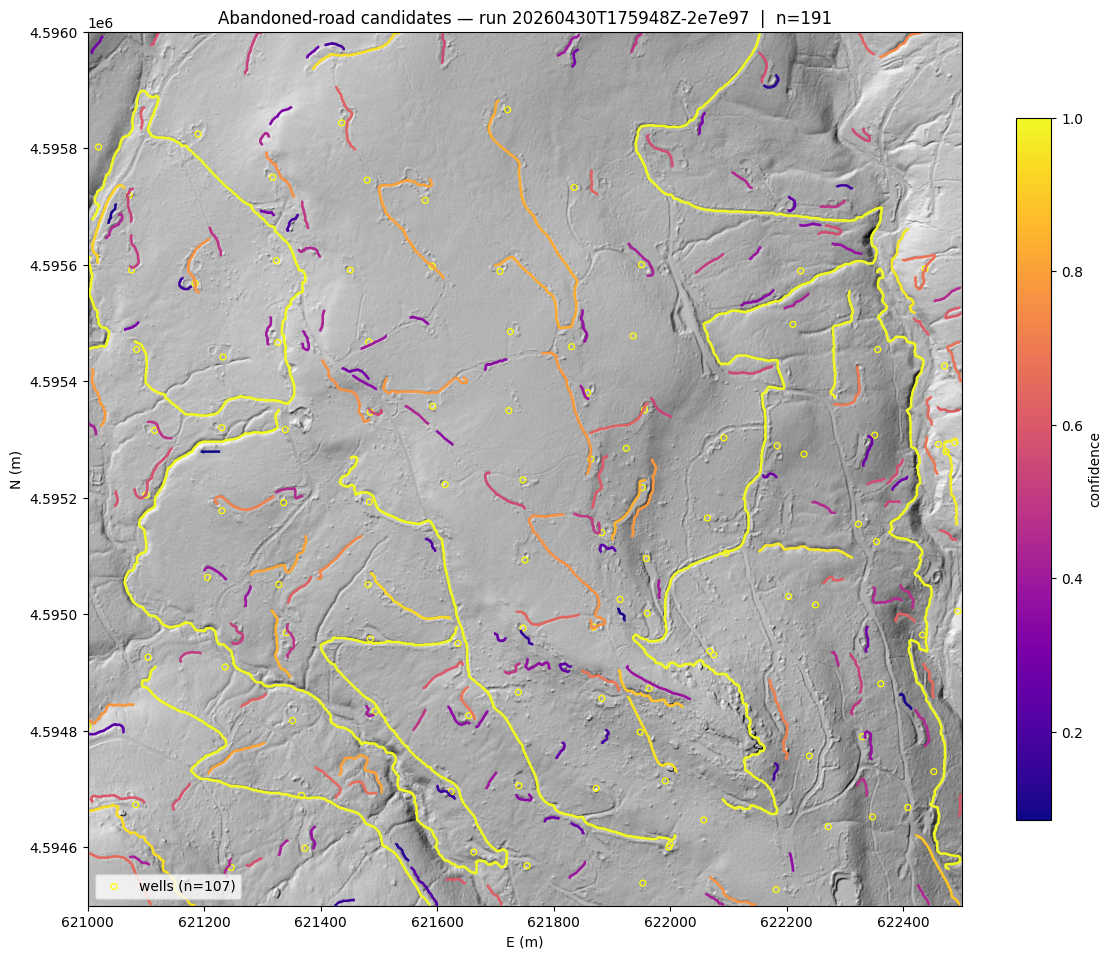

In [9]:
ext = (X0, X1, Y0, Y1)
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
if len(export) > 0:
    export.plot(ax=ax, column='confidence_score', cmap='plasma',
                linewidth=1.8, legend=True,
                legend_kwds={'label': 'confidence', 'shrink': 0.6})
ax.scatter(wells.geometry.x, wells.geometry.y, s=18, facecolors='none',
           edgecolors='yellow', linewidths=0.9, label=f'wells (n={len(wells)})')
ax.set_title(f'Abandoned-road candidates — run {RUN_ID}  |  n={len(export)}')
ax.legend(loc='lower left')
ax.set_xlabel('E (m)'); ax.set_ylabel('N (m)')
plt.tight_layout(); plt.show()

## 7. Append to analysis log

In [10]:
entry = (
    f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage D v0.6 road detector  run {RUN_ID}\n\n'
    f'- Method: {DETECTION_METHOD} (Meijering ridge filter on -LRM, multi-scale)\n'
    f'- Thresholds: ' + ', '.join(f"{k}={v}" for k,v in TH.items()) + '\n\n'
    f'- Raw skeleton components: {n_skel}\n'
    f'- Kept segments (>= {TH["min_segment_length_m"]:.0f} m): {len(roads)}\n'
    f'- Segment length: median {roads.length_m.median():.1f} m, p95 {roads.length_m.quantile(.95):.1f} m\n'
    f'- Nearest-well distance: median {roads.nearest_well_m.median():.1f} m\n'
    f'- Within {TH["positional_uncert_m"]:.0f} m: {roads.inside_positional_uncertainty.sum()} / {len(roads)}\n'
    f'- Output: candidates_roads.gpkg / .parquet\n'
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)


## 2026-04-30 17:59 UTC — Stage D v0.6 road detector  run 20260430T175948Z-2e7e97

- Method: road_v0.9_relaxed (Meijering ridge filter on -LRM, multi-scale)
- Thresholds: ridge_sigmas=(1.0, 2.0, 3.0), ridge_response_pct=85.0, closing_radius_cells=2, min_component_area_m2=120.0, min_eccentricity=0.82, min_segment_length_m=30.0, ground_density_min=1.0, positional_uncert_m=100.0, xsec_spacing_m=5.0, xsec_half_width_m=15.0, xsec_edge_min_width_m=2.0, xsec_edge_max_width_m=12.0

- Raw skeleton components: 229
- Kept segments (>= 30 m): 191
- Segment length: median 56.8 m, p95 286.9 m
- Nearest-well distance: median 42.7 m
- Within 100 m: 164 / 191
- Output: candidates_roads.gpkg / .parquet



C:\Users\colto\AppData\Local\Temp\ipykernel_42500\1300205151.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage D v0.6 road detector  run {RUN_ID}\n\n'
